## Load Data

In [1]:
#! pip install mne

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from utils import load_eeg_data, CHANNEL_GROUPS, FREQ_BANDS

# Define subjects for multi-subject analysis
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

CONDITION = "BLA"
CHANNELS = "BLA"   # T7, T8, TP7, TP8
FREQ_RANGE_LABEL = "delta_gamma"

import warnings
import contextlib
import io

all_epochs = {}
all_data = {}
loaded_subjects = []
failed_subjects = []

for SUBJECT_ID in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    SUBJECT_ID,
                    channels=CHANNELS,
                    freq_band=FREQ_RANGE_LABEL
                )

        data = epochs.get_data() * 1e6
        all_epochs[SUBJECT_ID] = epochs
        all_data[SUBJECT_ID] = data
        loaded_subjects.append(SUBJECT_ID)

    except Exception as e:
        failed_subjects.append((SUBJECT_ID, str(e)))

print("Loaded successfully:", loaded_subjects)

if failed_subjects:
    print("\nFailed to load:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")

Loaded successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


## Frequency Domain Analysis - Multiple Subjects

Analyze the power spectral density (PSD) of BLA trials in different frequency bands across multiple subjects to understand oscillatory activity patterns.

Frequency bands:
- Delta: 0.5–4 Hz
- Theta: 4–8 Hz
- Alpha: 8–13 Hz
- Beta: 13–30 Hz
- Gamma: 30–45 Hz

**Subjects to analyze:** 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17 (14 subjects)

In [2]:
# Test the function import
from utils import compute_frequency_power, load_eeg_data
print("Functions imported successfully")

# Define subjects to analyze
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]  # All available BLA subjects
CONDITION = "BLA"
CHANNELS = "BLA"
ROLLING_WINDOW = 5  # trials in the moving average

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")

Functions imported successfully
Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA


In [3]:
import warnings
import contextlib
import io

# ------------------------------------------------------------
# GOAL OF THIS CELL:
# 1) Load each subject's BLA epochs
# 2) Compute frequency-domain band power across the FULL epoch
# 3) Compute baseline band power using -500 to -50 ms
# 4) Subtract baseline power from full-epoch power
#
# IMPORTANT:
# all_power_pivots stores BASELINE-CENTERED absolute power.
# So a positive value means "more power than baseline",
# and a negative value means "less power than baseline".
#
# If you later want RELATIVE POWER (% of total power),
# do NOT start from all_power_pivots, because subtracting the
# baseline first can make totals small or negative and distort
# percentages. Relative-power cells should instead start from
# the raw power tables (all_power_dfs) and then baseline-center
# the percentages afterward.
# ------------------------------------------------------------

all_power_dfs = {}
all_power_pivots = {}
all_psds_dicts = {}
baseline_power_dfs = {}
baseline_power_pivots = {}
processed_subjects = []
failed_subjects = []

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

        # Baseline window used for centering
        baseline_epochs = epochs.copy().crop(tmin=-0.5, tmax=-0.05)
        baseline_power_df, _ = compute_frequency_power(baseline_epochs, fmin=0.5, fmax=45)
        baseline_power_pivot = (
            baseline_power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Raw band power over the full epoch
        power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)
        power_pivot = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Baseline-centered absolute power
        power_pivot_centered = power_pivot.subtract(baseline_power_pivot, fill_value=0)

        all_power_dfs[subject_id] = power_df
        all_power_pivots[subject_id] = power_pivot_centered
        all_psds_dicts[subject_id] = psds_dict
        baseline_power_dfs[subject_id] = baseline_power_df
        baseline_power_pivots[subject_id] = baseline_power_pivot
        processed_subjects.append(subject_id)

    except Exception as e:
        failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", processed_subjects)

if failed_subjects:
    print("\nFailed:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")

/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y,

Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


# BLA Frequency Domain Absolute Power All Times

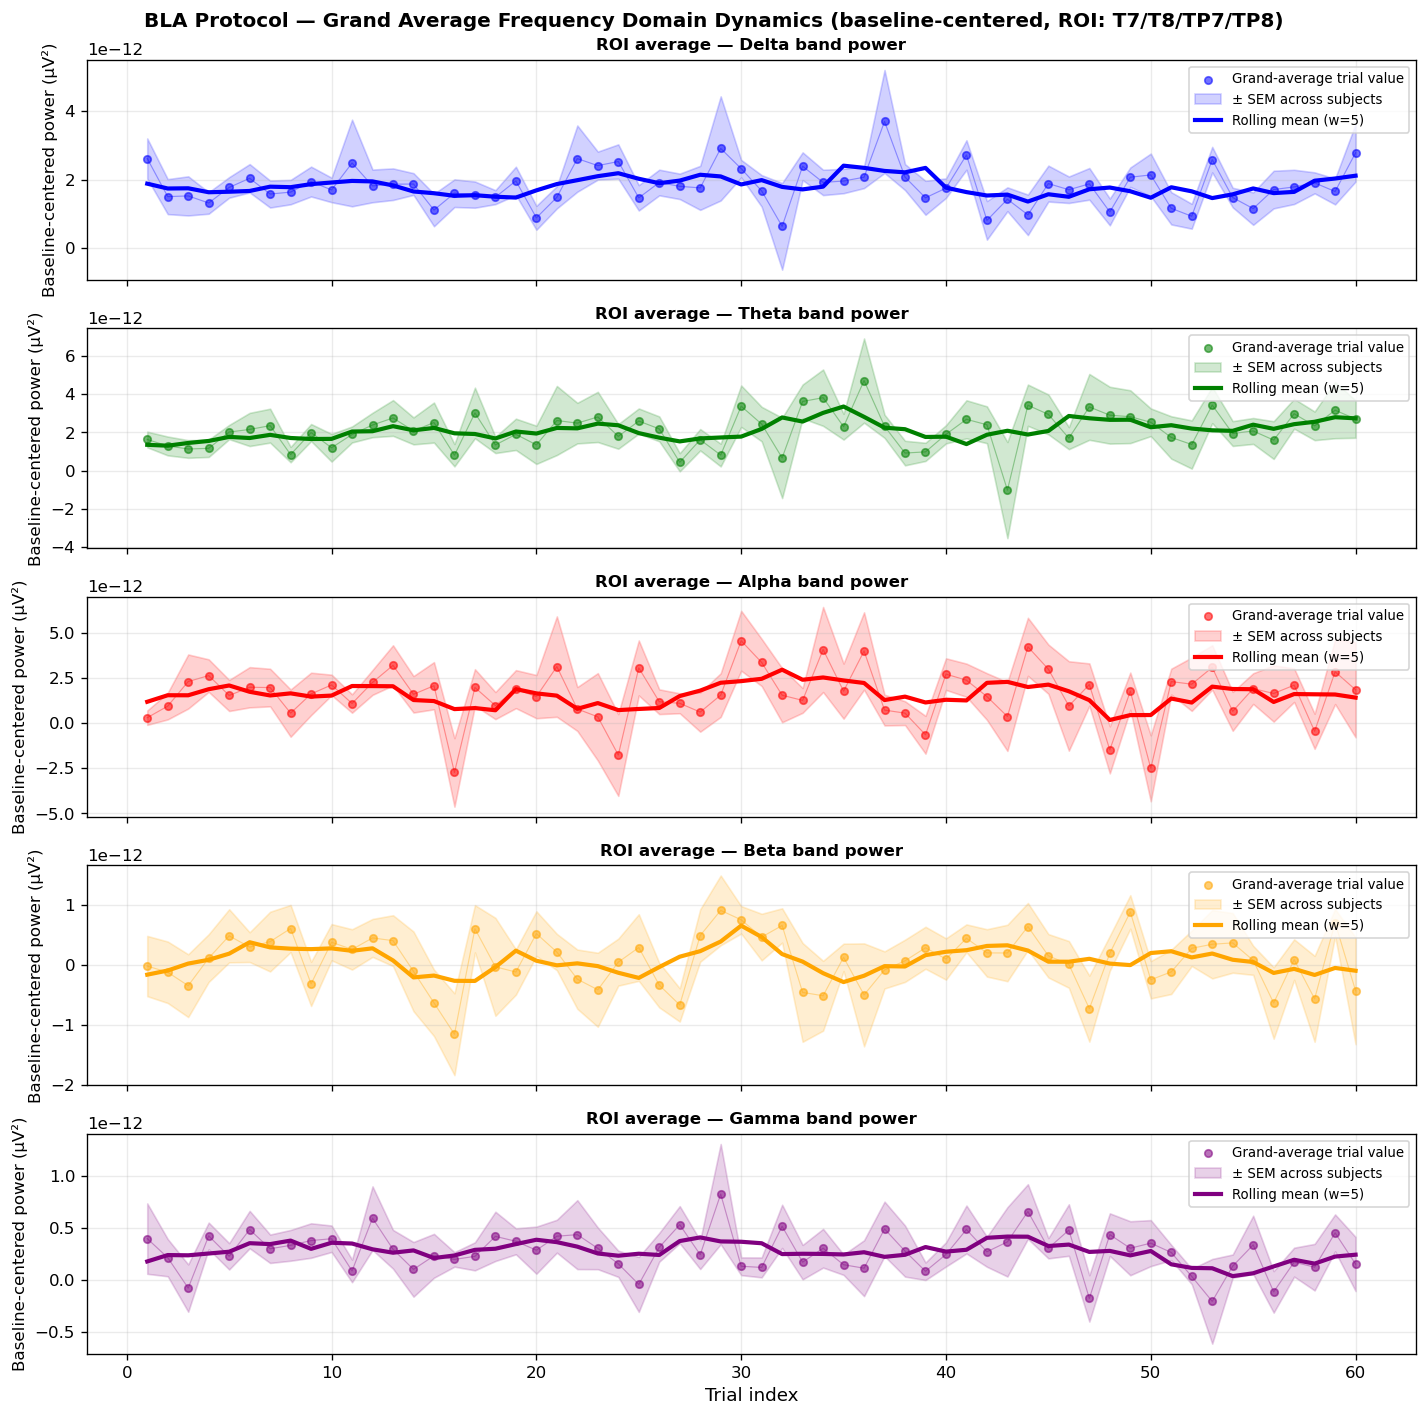

Figure saved: frequency_dynamics_BLA_grand_average.png
Analysis completed for subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Positive values = above baseline; negative values = below baseline.


In [4]:
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

# ------------------------------------------------------------
# This figure shows BASELINE-CENTERED absolute power by trial.
# Each point is the grand average across subjects at that trial.
# The thick line is a rolling mean to make long-term trends easier
# to see across noisy trial-by-trial values.
# ------------------------------------------------------------

grand_power = {}
grand_sem = {}

for band in bands:
    band_trials = []
    for subject_id in processed_subjects:
        power_pivot = all_power_pivots[subject_id]
        if band in power_pivot.columns:
            band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_power[band] = band_df.mean(axis=1)
        grand_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]
    if band in grand_power:
        values = grand_power[band].values
        errors = grand_sem[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Grand-average trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM across subjects'
        )

        rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(trial_idx, rolling, color=color, linewidth=2.5, zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})')

    ax.set_ylabel('Baseline-centered power (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    'BLA Protocol — Grand Average Frequency Domain Dynamics (baseline-centered, ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)
fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_dynamics_BLA_grand_average.png")
print(f"Analysis completed for subjects: {processed_subjects}")
print("Positive values = above baseline; negative values = below baseline.")

# BLA Frequency Domain Absolute Power 0-500ms

/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y,

Processed successfully (0–500 ms): [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


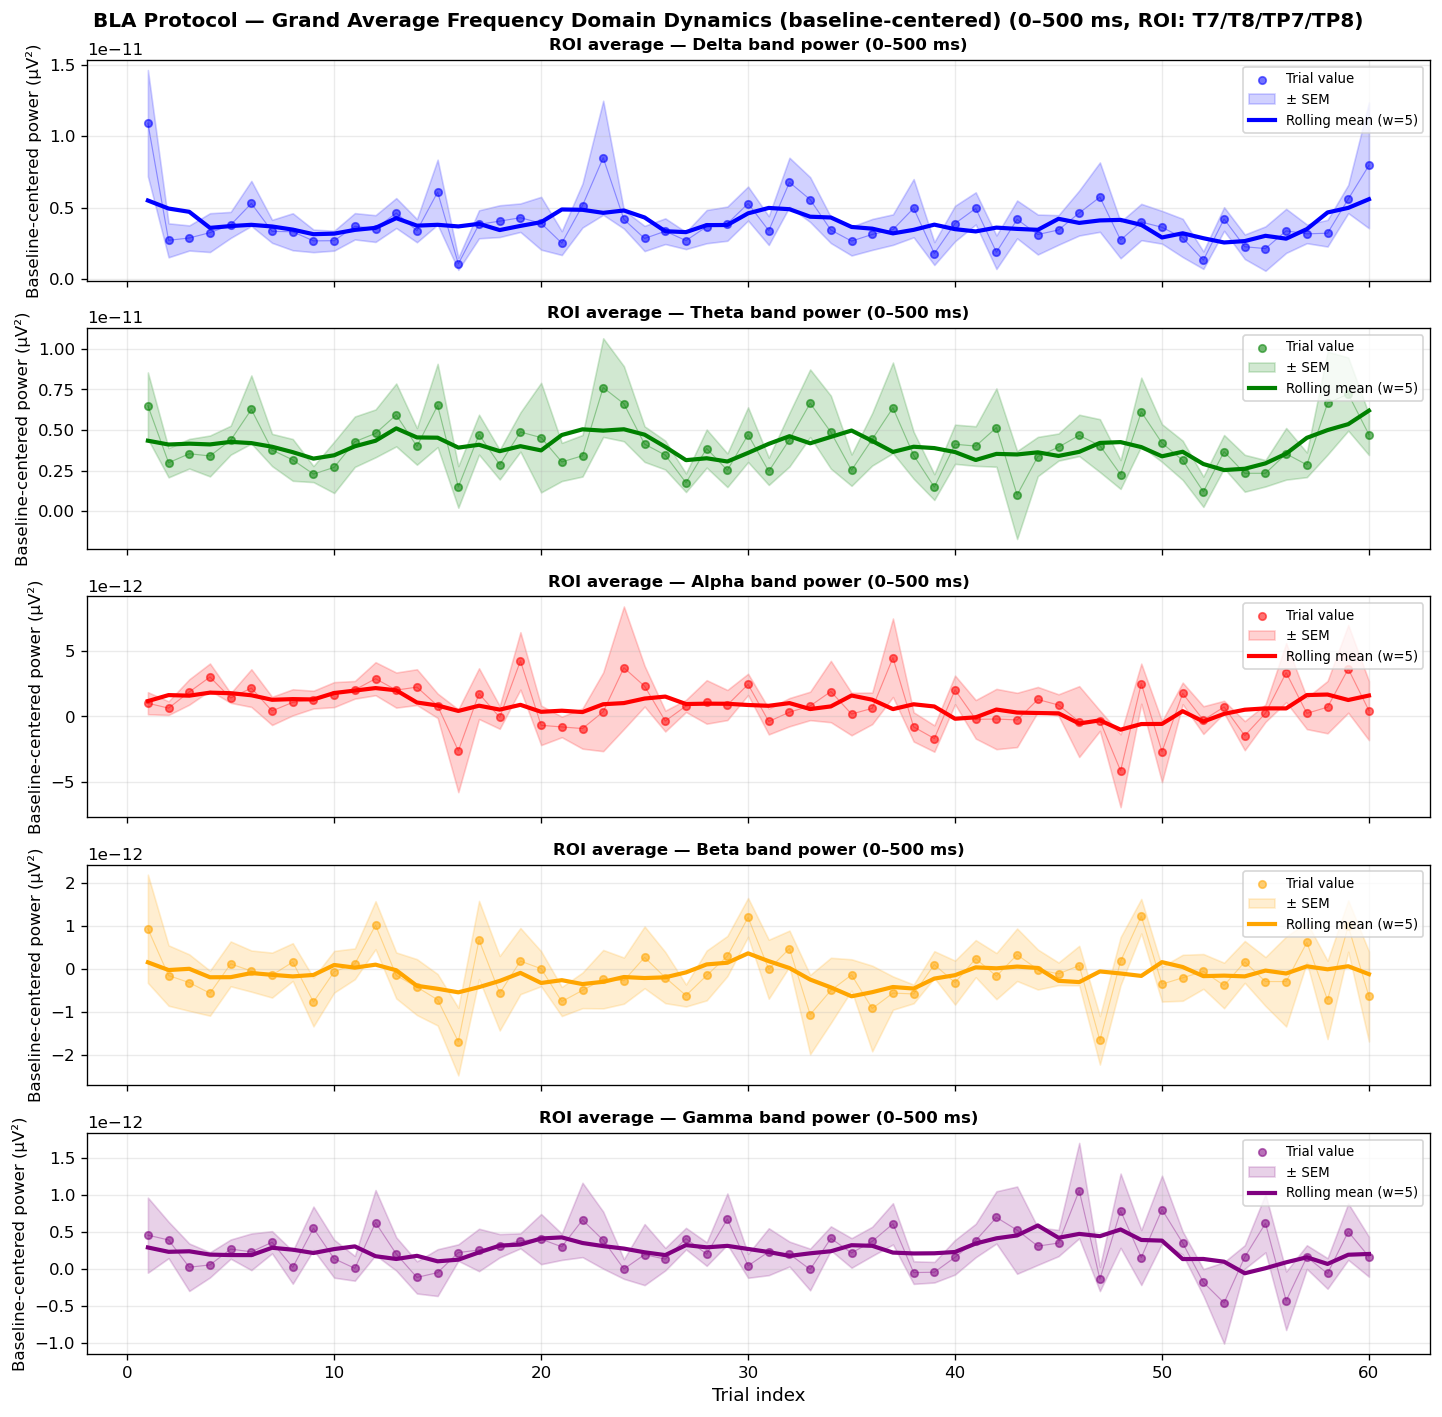

Figure saved: frequency_dynamics_BLA_grand_average_0_500ms.png


In [5]:
# --- Frequency-domain absolute power using only 0–500 ms ---

import warnings
import contextlib
import io

all_power_dfs_0_500 = {}
all_power_pivots_0_500 = {}
all_psds_dicts_0_500 = {}
baseline_power_dfs_0_500 = {}
baseline_power_pivots_0_500 = {}
processed_subjects_0_500 = []
failed_subjects_0_500 = []

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

        baseline_epochs = epochs.copy().crop(tmin=-0.5, tmax=-0.05)
        baseline_power_df, _ = compute_frequency_power(baseline_epochs, fmin=0.5, fmax=45)
        baseline_power_pivot = (
            baseline_power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Keep only 0 to 500 ms
        epochs_0_500 = epochs.copy().crop(tmin=0.0, tmax=0.5)

        # Compute frequency-domain power on the cropped window
        power_df, psds_dict = compute_frequency_power(epochs_0_500, fmin=0.5, fmax=45)

        power_pivot = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        power_pivot = power_pivot.subtract(baseline_power_pivot, fill_value=0)

        all_power_dfs_0_500[subject_id] = power_df
        all_power_pivots_0_500[subject_id] = power_pivot
        all_psds_dicts_0_500[subject_id] = psds_dict
        baseline_power_dfs_0_500[subject_id] = baseline_power_df
        baseline_power_pivots_0_500[subject_id] = baseline_power_pivot
        processed_subjects_0_500.append(subject_id)

    except Exception as e:
        failed_subjects_0_500.append((subject_id, str(e)))

print("Processed successfully (0–500 ms):", processed_subjects_0_500)

if failed_subjects_0_500:
    print("\nFailed:")
    for subject_id, err in failed_subjects_0_500:
        print(f"Subject {subject_id}: {err}")

# Build grand-average power table across subjects
grand_power_0_500 = {}
grand_sem_0_500 = {}

for band in bands:
    band_trials = []
    for subject_id in processed_subjects_0_500:
        power_pivot = all_power_pivots_0_500[subject_id]
        if band in power_pivot.columns:
            band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_power_0_500[band] = band_df.mean(axis=1)
        grand_sem_0_500[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Plot
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_power_0_500:
        values = grand_power_0_500[band].values
        errors = grand_sem_0_500[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(
            trial_idx,
            rolling,
            color=color,
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Baseline-centered power (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power (0–500 ms)', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    'BLA Protocol — Grand Average Frequency Domain Dynamics (baseline-centered) (0–500 ms, ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_grand_average_0_500ms.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_dynamics_BLA_grand_average_0_500ms.png")


In [ ]:
# BLA Frequency Domain Absolute Power 500-1000ms

/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y,

Processed successfully (500–1000 ms): [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


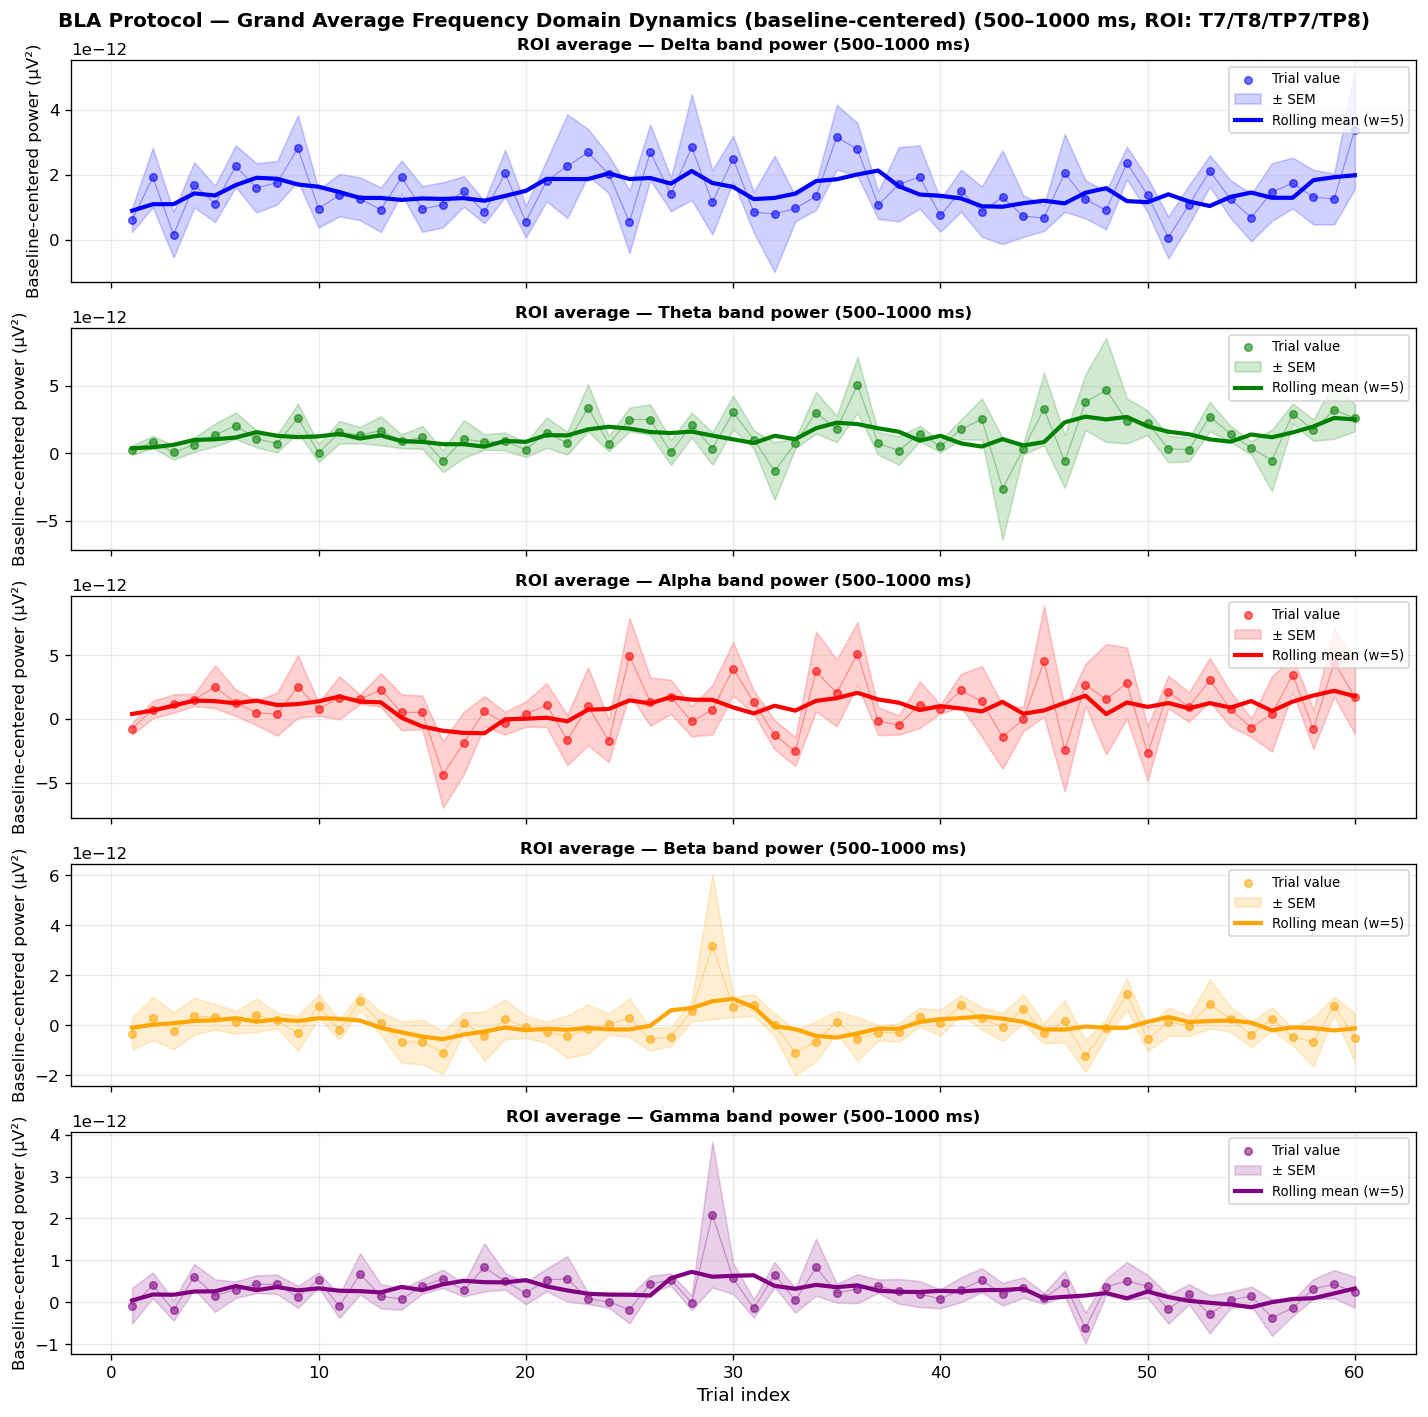

Figure saved: frequency_dynamics_BLA_grand_average_500_1000ms.png


In [6]:
# --- Frequency-domain absolute power using only 500–1000 ms ---

import warnings
import contextlib
import io

all_power_dfs_500_1000 = {}
all_power_pivots_500_1000 = {}
all_psds_dicts_500_1000 = {}
baseline_power_dfs_500_1000 = {}
baseline_power_pivots_500_1000 = {}
processed_subjects_500_1000 = []
failed_subjects_500_1000 = []

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

        baseline_epochs = epochs.copy().crop(tmin=-0.5, tmax=-0.05)
        baseline_power_df, _ = compute_frequency_power(baseline_epochs, fmin=0.5, fmax=45)
        baseline_power_pivot = (
            baseline_power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Keep only 500 to 1000 ms
        epochs_500_1000 = epochs.copy().crop(tmin=0.5, tmax=1.0)

        # Compute frequency-domain power on the cropped window
        power_df, psds_dict = compute_frequency_power(epochs_500_1000, fmin=0.5, fmax=45)

        power_pivot = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        power_pivot = power_pivot.subtract(baseline_power_pivot, fill_value=0)

        all_power_dfs_500_1000[subject_id] = power_df
        all_power_pivots_500_1000[subject_id] = power_pivot
        all_psds_dicts_500_1000[subject_id] = psds_dict
        baseline_power_dfs_500_1000[subject_id] = baseline_power_df
        baseline_power_pivots_500_1000[subject_id] = baseline_power_pivot
        processed_subjects_500_1000.append(subject_id)

    except Exception as e:
        failed_subjects_500_1000.append((subject_id, str(e)))

print("Processed successfully (500–1000 ms):", processed_subjects_500_1000)

if failed_subjects_500_1000:
    print("\nFailed:")
    for subject_id, err in failed_subjects_500_1000:
        print(f"Subject {subject_id}: {err}")

# Build grand-average power table across subjects
grand_power_500_1000 = {}
grand_sem_500_1000 = {}

for band in bands:
    band_trials = []
    for subject_id in processed_subjects_500_1000:
        power_pivot = all_power_pivots_500_1000[subject_id]
        if band in power_pivot.columns:
            band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_power_500_1000[band] = band_df.mean(axis=1)
        grand_sem_500_1000[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Plot
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_power_500_1000:
        values = grand_power_500_1000[band].values
        errors = grand_sem_500_1000[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(
            trial_idx,
            rolling,
            color=color,
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Baseline-centered power (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power (500–1000 ms)', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    'BLA Protocol — Grand Average Frequency Domain Dynamics (baseline-centered) (500–1000 ms, ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_grand_average_500_1000ms.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_dynamics_BLA_grand_average_500_1000ms.png")


# BLA Frequency Domain Relative Power All Times

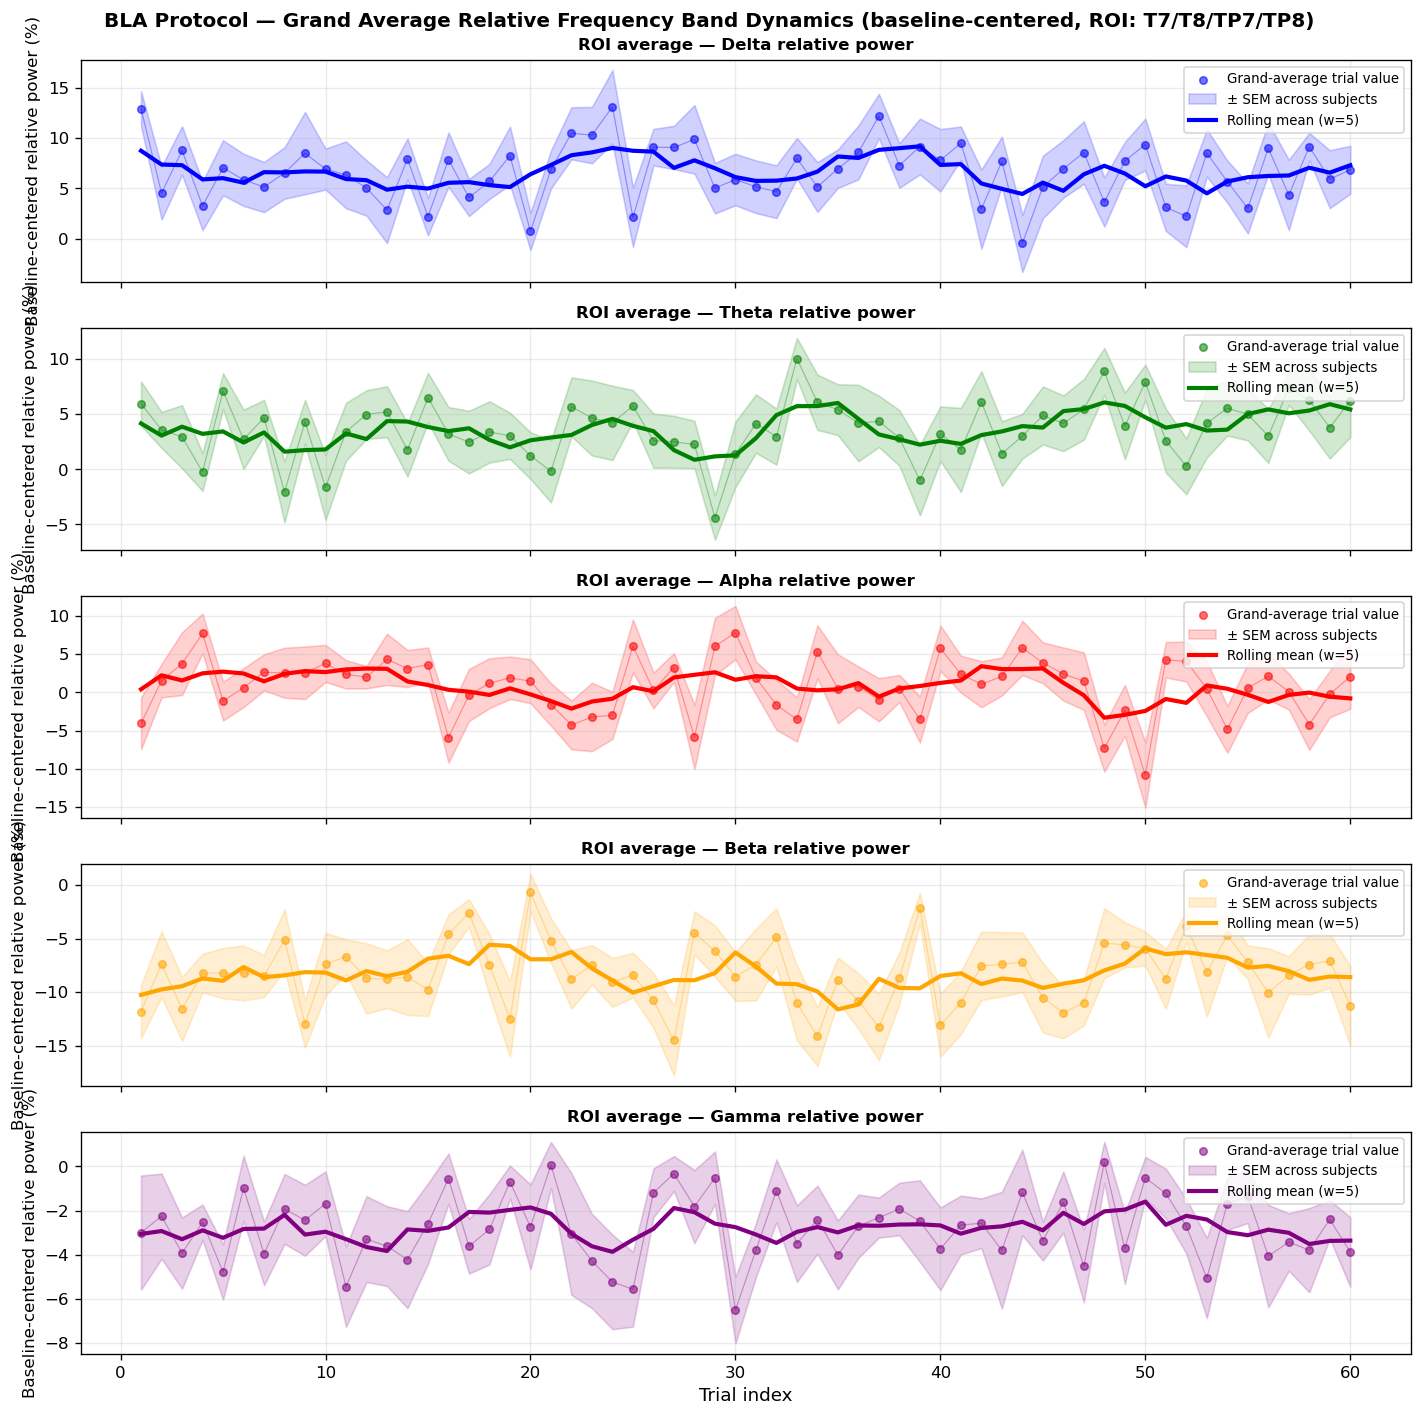

Figure saved: relative_frequency_dynamics_BLA_grand_average.png
Relative power is computed from RAW band power, then baseline-centered.
Because the percentages are baseline-centered, the band sums are expected to be near 0%, not 100%.


In [7]:
# --- Relative power grand-average plots (fixed to avoid distorted percentages) ---

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

# ------------------------------------------------------------
# IMPORTANT FIX:
# Relative power must be computed from RAW absolute power first.
# If we compute percentages from baseline-subtracted power, the
# denominator can become very small or negative, which creates
# huge spikes or weird-looking graphs.
#
# Correct order:
#   raw absolute power  ->  relative % of total  ->  baseline-center %
# ------------------------------------------------------------

all_relative_power_pivots = {}
relative_subject_tables = []

for subject_id in processed_subjects:
    # Raw full-epoch absolute power (NOT baseline-subtracted)
    raw_power_pivot = (
        all_power_dfs[subject_id]
        .groupby(['trial', 'band'])['power']
        .mean()
        .unstack()
        .reindex(columns=bands)
    )

    # Raw baseline absolute power
    baseline_raw_power_pivot = (
        baseline_power_dfs[subject_id]
        .groupby(['trial', 'band'])['power']
        .mean()
        .unstack()
        .reindex(columns=bands)
    )

    raw_power_pivot = raw_power_pivot.reset_index(drop=True)
    baseline_raw_power_pivot = baseline_raw_power_pivot.reset_index(drop=True)

    # Convert to % of total band power within each trial
    total_power_per_trial = raw_power_pivot.sum(axis=1)
    baseline_total_power_per_trial = baseline_raw_power_pivot.sum(axis=1)

    relative_power_pivot = raw_power_pivot.div(total_power_per_trial, axis=0) * 100
    baseline_relative_power_pivot = baseline_raw_power_pivot.div(baseline_total_power_per_trial, axis=0) * 100

    # Baseline-center the percentages
    relative_power_centered = relative_power_pivot.subtract(baseline_relative_power_pivot, fill_value=0)

    all_relative_power_pivots[subject_id] = relative_power_centered

    # Long format keeps all bands aligned by subject + trial index
    temp = relative_power_centered.copy()
    temp["subject_id"] = subject_id
    temp["trial_idx"] = np.arange(1, len(temp) + 1)
    relative_subject_tables.append(temp)

relative_long = pd.concat(relative_subject_tables, ignore_index=True)

# Grand mean and SEM across subjects, aligned by trial number
grand_relative_mean = relative_long.groupby("trial_idx")[bands].mean()
grand_relative_sem = relative_long.groupby("trial_idx")[bands].sem()

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)
trial_idx = grand_relative_mean.index.values

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]
    values = grand_relative_mean[band].values
    errors = grand_relative_sem[band].values

    ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Grand-average trial value')
    ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

    ax.fill_between(
        trial_idx,
        values - errors,
        values + errors,
        color=color,
        alpha=0.18,
        zorder=1,
        label='± SEM across subjects'
    )

    rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
    ax.plot(
        trial_idx,
        rolling,
        color=color,
        linewidth=2.5,
        zorder=3,
        label=f'Rolling mean (w={ROLLING_WINDOW})'
    )

    ax.set_ylabel('Baseline-centered relative power (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    'BLA Protocol — Grand Average Relative Frequency Band Dynamics (baseline-centered, ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('relative_frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: relative_frequency_dynamics_BLA_grand_average.png")
print("Relative power is computed from RAW band power, then baseline-centered.")
print("Because the percentages are baseline-centered, the band sums are expected to be near 0%, not 100%.")

# BLA Frequency Domain Relative Power 0-500ms

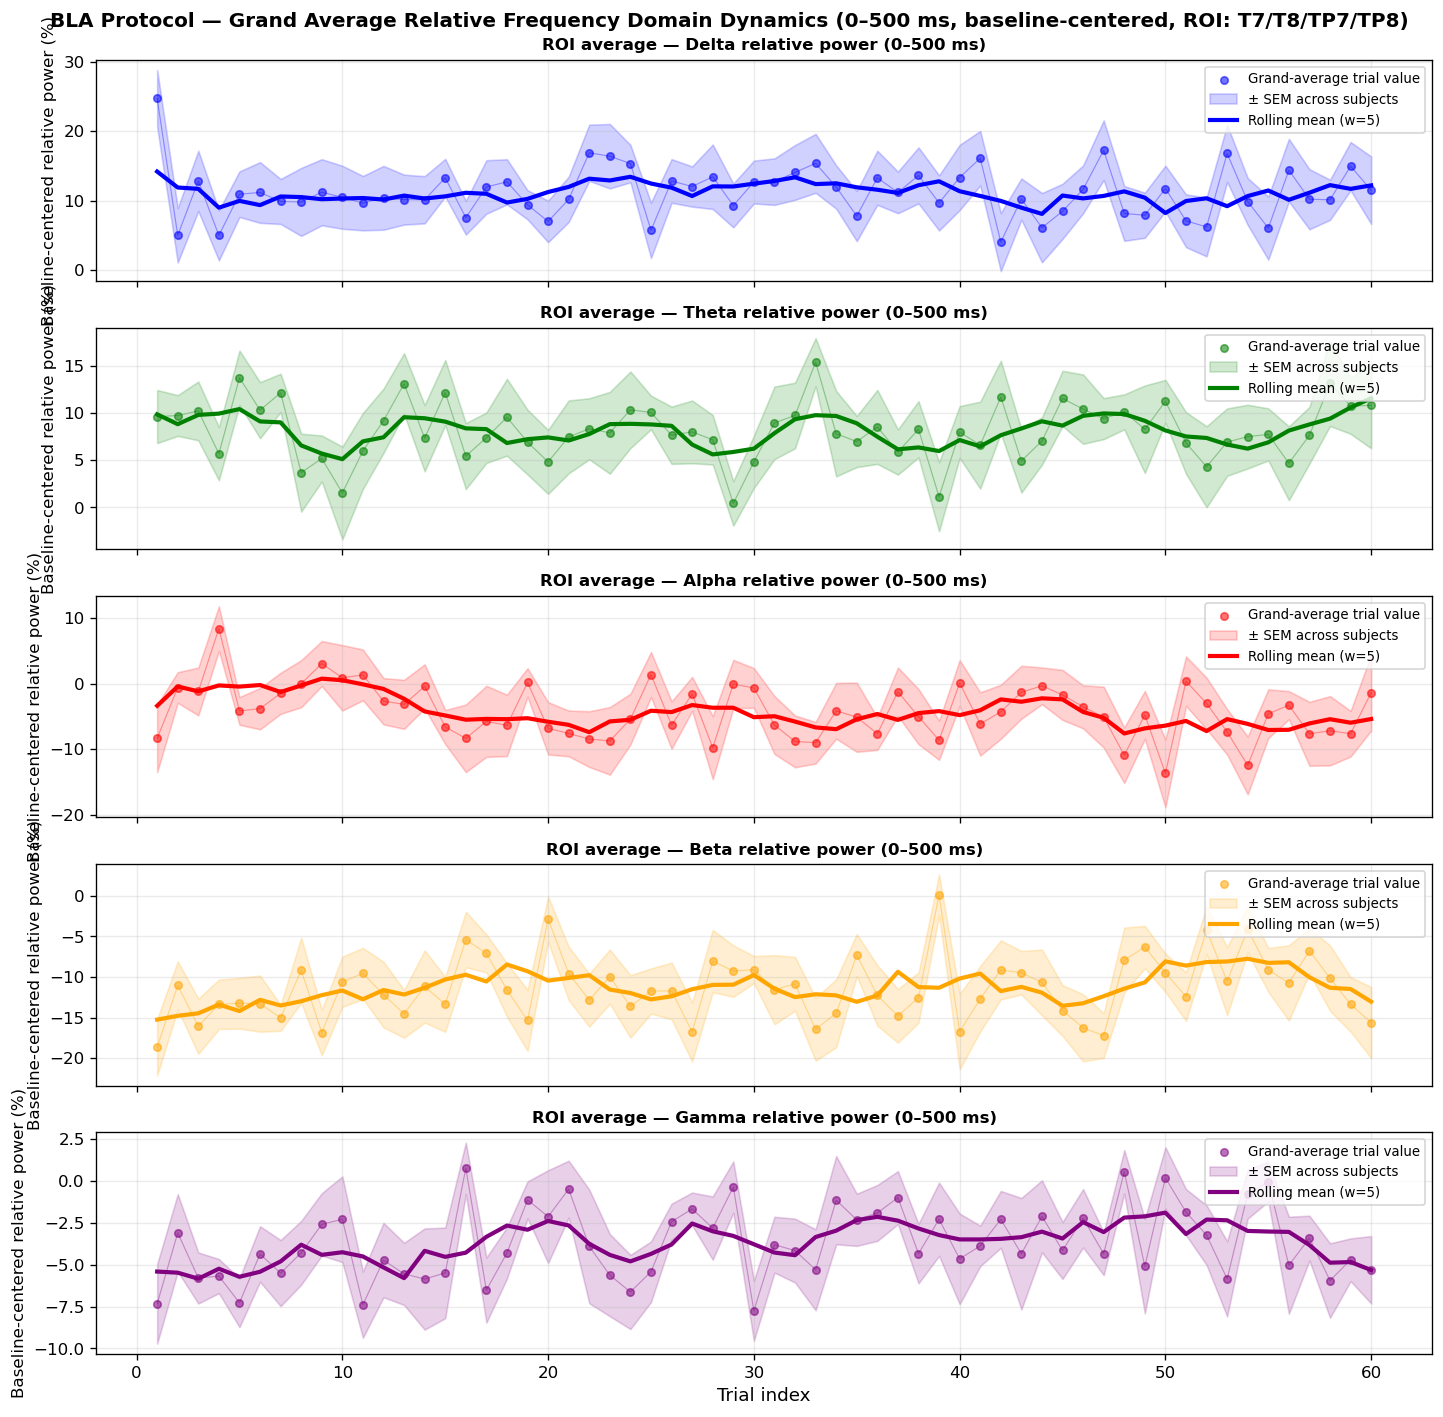

Figure saved: relative_frequency_dynamics_BLA_grand_average_0_500ms.png
Because these percentages are baseline-centered, row sums should be near 0%, not 100%.

Per-subject row sums (0–500 ms):
Subject 2: min=-0.000000, max=0.000000
Subject 3: min=-0.000000, max=0.000000
Subject 5: min=-0.000000, max=0.000000
Subject 6: min=-0.000000, max=0.000000
Subject 7: min=-0.000000, max=0.000000
Subject 8: min=-0.000000, max=0.000000
Subject 9: min=-0.000000, max=0.000000
Subject 10: min=-0.000000, max=0.000000
Subject 11: min=-0.000000, max=0.000000
Subject 12: min=-0.000000, max=0.000000
Subject 13: min=-0.000000, max=0.000000
Subject 15: min=-0.000000, max=0.000000
Subject 16: min=-0.000000, max=0.000000
Subject 17: min=-0.000000, max=0.000000


In [8]:
# --- Relative frequency-domain power using only 0–500 ms (fixed) ---

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

# Compute baseline-centered relative power (%) for each subject.
# IMPORTANT: start from RAW power, convert to %, THEN subtract baseline %.

all_relative_power_pivots_0_500 = {}

for subject_id in processed_subjects_0_500:
    raw_power_pivot = (
        all_power_dfs_0_500[subject_id]
        .groupby(['trial', 'band'])['power']
        .mean()
        .unstack()
        .reindex(columns=bands)
    )

    baseline_raw_power_pivot = (
        baseline_power_dfs_0_500[subject_id]
        .groupby(['trial', 'band'])['power']
        .mean()
        .unstack()
        .reindex(columns=bands)
    )

    total_power_per_trial = raw_power_pivot.sum(axis=1)
    baseline_total_power_per_trial = baseline_raw_power_pivot.sum(axis=1)

    relative_power_pivot = raw_power_pivot.div(total_power_per_trial, axis=0) * 100
    baseline_relative_power_pivot = baseline_raw_power_pivot.div(baseline_total_power_per_trial, axis=0) * 100

    relative_power_centered = relative_power_pivot.subtract(baseline_relative_power_pivot, fill_value=0)
    all_relative_power_pivots_0_500[subject_id] = relative_power_centered

grand_relative_power_0_500 = {}
grand_relative_sem_0_500 = {}

for band in bands:
    band_trials = []
    for subject_id in processed_subjects_0_500:
        relative_power_pivot = all_relative_power_pivots_0_500[subject_id]
        if band in relative_power_pivot.columns:
            band_trials.append(relative_power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power_0_500[band] = band_df.mean(axis=1)
        grand_relative_sem_0_500[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power_0_500:
        values = grand_relative_power_0_500[band].values
        errors = grand_relative_sem_0_500[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Grand-average trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM across subjects'
        )

        rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(
            trial_idx,
            rolling,
            color=color,
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Baseline-centered relative power (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power (0–500 ms)', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    'BLA Protocol — Grand Average Relative Frequency Domain Dynamics (0–500 ms, baseline-centered, ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('relative_frequency_dynamics_BLA_grand_average_0_500ms.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: relative_frequency_dynamics_BLA_grand_average_0_500ms.png")
print("Because these percentages are baseline-centered, row sums should be near 0%, not 100%.")

print("\nPer-subject row sums (0–500 ms):")
for subject_id in processed_subjects_0_500:
    row_sums = all_relative_power_pivots_0_500[subject_id][bands].sum(axis=1)
    print(f"Subject {subject_id}: min={row_sums.min():.6f}, max={row_sums.max():.6f}")

# BLA Frequency Domain Relative Power 500-1000ms

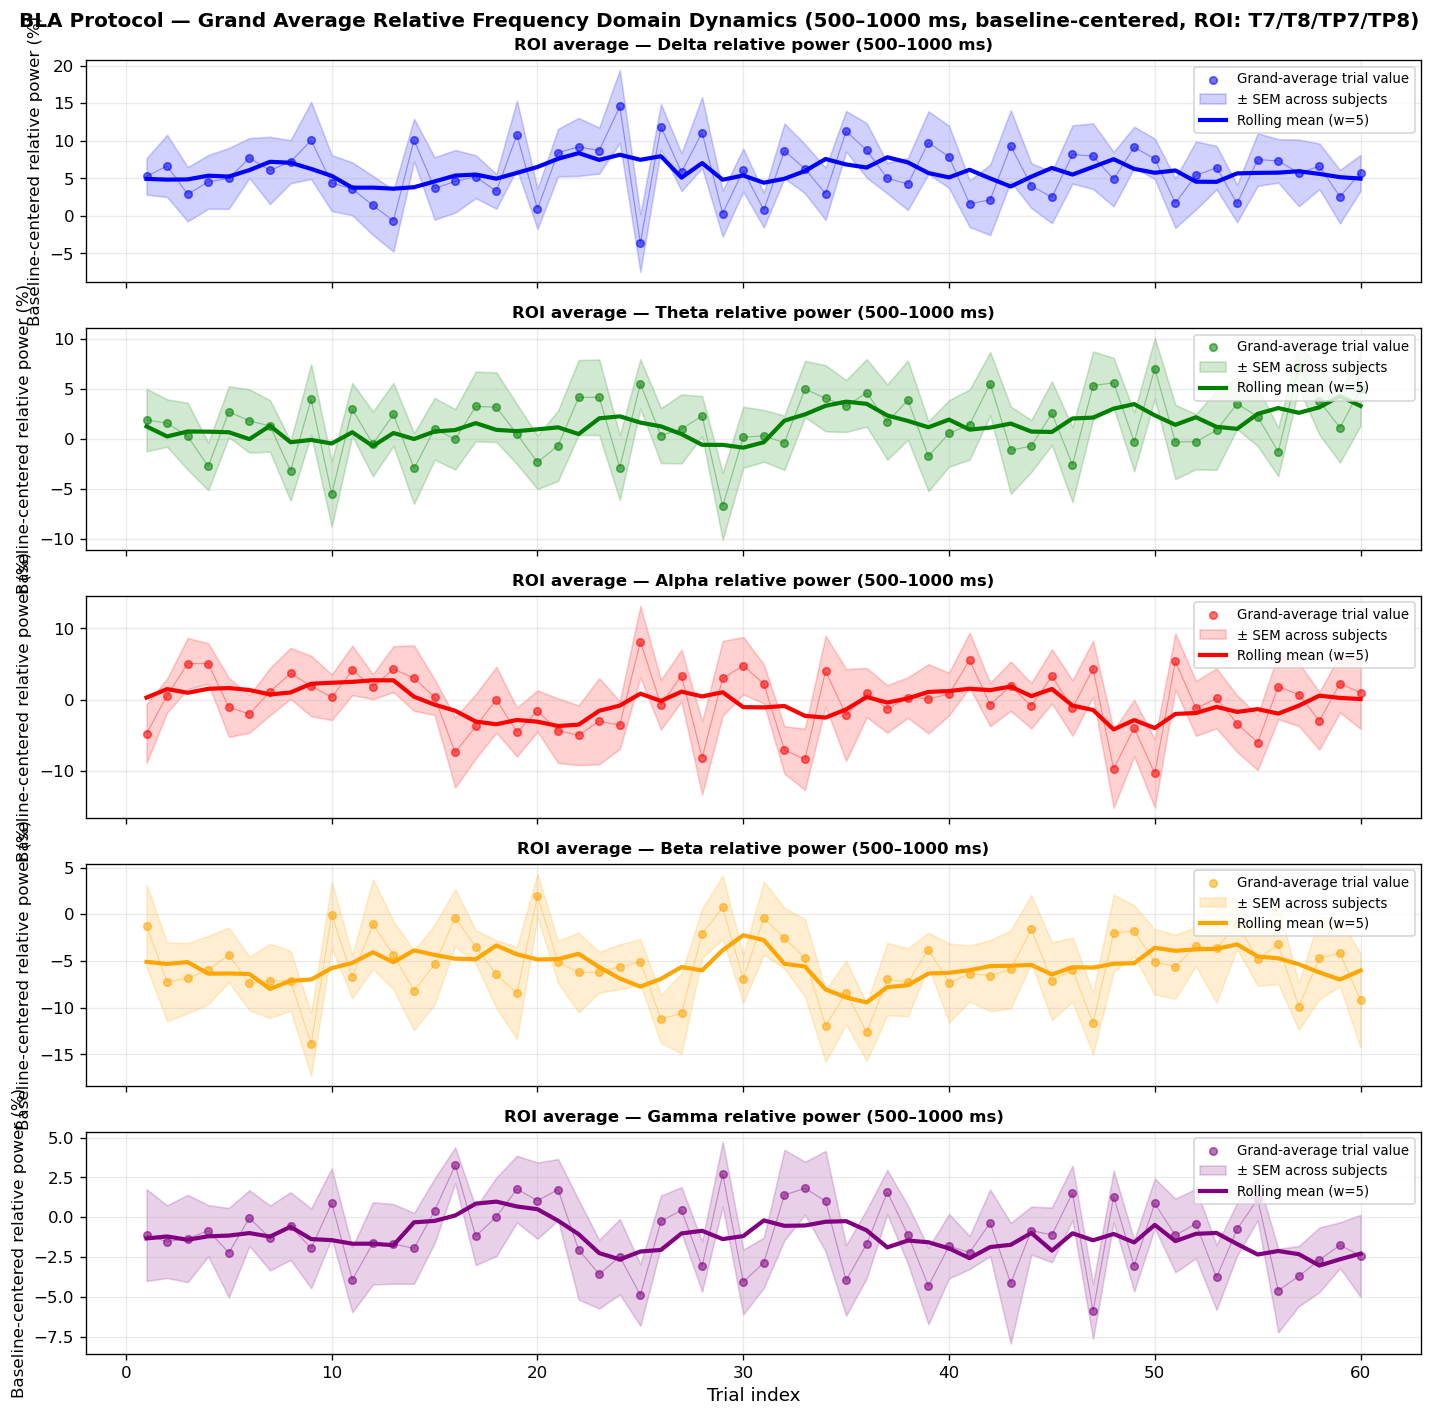

Figure saved: relative_frequency_dynamics_BLA_grand_average_500_1000ms.png
Because these percentages are baseline-centered, row sums should be near 0%, not 100%.

Per-subject row sums (500–1000 ms):
Subject 2: min=-0.000000, max=0.000000
Subject 3: min=-0.000000, max=0.000000
Subject 5: min=-0.000000, max=0.000000
Subject 6: min=-0.000000, max=0.000000
Subject 7: min=-0.000000, max=0.000000
Subject 8: min=-0.000000, max=0.000000
Subject 9: min=-0.000000, max=0.000000
Subject 10: min=-0.000000, max=0.000000
Subject 11: min=-0.000000, max=0.000000
Subject 12: min=-0.000000, max=0.000000
Subject 13: min=-0.000000, max=0.000000
Subject 15: min=-0.000000, max=0.000000
Subject 16: min=-0.000000, max=0.000000
Subject 17: min=-0.000000, max=0.000000


In [9]:
# --- Relative frequency-domain power using only 500–1000 ms (fixed) ---

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

all_relative_power_pivots_500_1000 = {}

for subject_id in processed_subjects_500_1000:
    raw_power_pivot = (
        all_power_dfs_500_1000[subject_id]
        .groupby(['trial', 'band'])['power']
        .mean()
        .unstack()
        .reindex(columns=bands)
    )

    baseline_raw_power_pivot = (
        baseline_power_dfs_500_1000[subject_id]
        .groupby(['trial', 'band'])['power']
        .mean()
        .unstack()
        .reindex(columns=bands)
    )

    total_power_per_trial = raw_power_pivot.sum(axis=1)
    baseline_total_power_per_trial = baseline_raw_power_pivot.sum(axis=1)

    relative_power_pivot = raw_power_pivot.div(total_power_per_trial, axis=0) * 100
    baseline_relative_power_pivot = baseline_raw_power_pivot.div(baseline_total_power_per_trial, axis=0) * 100

    relative_power_centered = relative_power_pivot.subtract(baseline_relative_power_pivot, fill_value=0)
    all_relative_power_pivots_500_1000[subject_id] = relative_power_centered

grand_relative_power_500_1000 = {}
grand_relative_sem_500_1000 = {}

for band in bands:
    band_trials = []
    for subject_id in processed_subjects_500_1000:
        relative_power_pivot = all_relative_power_pivots_500_1000[subject_id]
        if band in relative_power_pivot.columns:
            band_trials.append(relative_power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power_500_1000[band] = band_df.mean(axis=1)
        grand_relative_sem_500_1000[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power_500_1000:
        values = grand_relative_power_500_1000[band].values
        errors = grand_relative_sem_500_1000[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Grand-average trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM across subjects'
        )

        rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(
            trial_idx,
            rolling,
            color=color,
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Baseline-centered relative power (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power (500–1000 ms)', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    'BLA Protocol — Grand Average Relative Frequency Domain Dynamics (500–1000 ms, baseline-centered, ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('relative_frequency_dynamics_BLA_grand_average_500_1000ms.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: relative_frequency_dynamics_BLA_grand_average_500_1000ms.png")
print("Because these percentages are baseline-centered, row sums should be near 0%, not 100%.")

print("\nPer-subject row sums (500–1000 ms):")
for subject_id in processed_subjects_500_1000:
    row_sums = all_relative_power_pivots_500_1000[subject_id][bands].sum(axis=1)
    print(f"Subject {subject_id}: min={row_sums.min():.6f}, max={row_sums.max():.6f}")

# BLA Time_Frequency Domain Absolute Power

In [10]:
# Import time-frequency functions
import mne
from mne.time_frequency import tfr_morlet

# Time-frequency analysis parameters
TF_N_CYCLES = 2.0
TF_FREQS = np.logspace(np.log10(1), np.log10(45), 20)  # 1–45 Hz, log-spaced

# Match the rest of the notebook
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
CONDITION = "BLA"
CHANNELS = "BLA"

print("Time-frequency analysis parameters:")
print(f"Frequencies: {TF_FREQS[0]:.1f} - {TF_FREQS[-1]:.1f} Hz ({len(TF_FREQS)} points)")
print(f"Wavelet cycles: {TF_N_CYCLES}")
print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")



Time-frequency analysis parameters:
Frequencies: 1.0 - 45.0 Hz (20 points)
Wavelet cycles: 2.0
Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA


In [11]:
import warnings
import contextlib
import io

# ------------------------------------------------------------
# GOAL OF THIS CELL:
# 1) Compute a Morlet-wavelet time-frequency representation (TFR)
#    for each ROI channel in each subject.
# 2) Average those channels together to get one ROI-level TFR.
# 3) Average over frequencies inside each canonical band
#    (delta/theta/alpha/beta/gamma).
# 4) Subtract the PRE-stimulus baseline mean (-500 to -50 ms)
#    from each trial separately.
#
# Result:
# tf_power_pivots[subject][band] is a trial x time table of
# BASELINE-CENTERED absolute power for that band.
#
# tf_power_pivots_raw keeps the same quantity BEFORE subtracting
# baseline, which is useful when computing relative power later.
# ------------------------------------------------------------

tf_power_dfs = {}
tf_power_pivots = {}
tf_power_pivots_raw = {}
tf_processed_subjects = []
tf_failed_subjects = []

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                data = epochs.get_data() * 1e6
                n_trials, n_channels, n_times = data.shape
                ch_names = epochs.ch_names

                epochs_tf = epochs.copy()
                epochs_tf._data = data / 1e6   # back to volts for MNE

                tfr_data = []
                for ch in ch_names:
                    tfr = tfr_morlet(
                        epochs_tf.copy().pick([ch]),
                        freqs=TF_FREQS,
                        n_cycles=TF_N_CYCLES,
                        average=False,
                        return_itc=False,
                        verbose=False
                    )

                    power = tfr.data                       # shape: trials x 1 x freqs x times
                    power_avg = power.mean(axis=1)        # remove singleton channel dimension
                    tfr_data.append(power_avg)

                roi_power = np.mean(tfr_data, axis=0)     # shape: trials x freqs x times
                times_ms = tfr.times * 1000

                band_power_over_time = {}
                band_power_over_time_raw = {}
                baseline_mask = (times_ms >= -500) & (times_ms <= -50)

                for band, (fmin, fmax) in FREQ_BANDS.items():
                    freq_mask = (TF_FREQS >= fmin) & (TF_FREQS <= fmax)
                    if freq_mask.any():
                        band_power = roi_power[:, freq_mask, :].mean(axis=1)
                        baseline_mean = band_power[:, baseline_mask].mean(axis=1, keepdims=True)
                        band_power_centered = band_power - baseline_mean

                        band_power_over_time[band] = band_power_centered
                        band_power_over_time_raw[band] = band_power

                tf_features = []
                for trial in range(n_trials):
                    for time_idx, time_val in enumerate(times_ms):
                        row = {
                            'trial': trial + 1,
                            'time_ms': time_val
                        }
                        for band in FREQ_BANDS.keys():
                            if band in band_power_over_time:
                                row[f'{band}_power'] = band_power_over_time[band][trial, time_idx]
                        tf_features.append(row)

                tf_df = pd.DataFrame(tf_features)

                tf_pivot = {}
                tf_pivot_raw = {}
                for band in FREQ_BANDS.keys():
                    if band in band_power_over_time:
                        tf_pivot[band] = pd.DataFrame(
                            band_power_over_time[band],
                            index=np.arange(1, n_trials + 1),
                            columns=times_ms
                        )
                        tf_pivot_raw[band] = pd.DataFrame(
                            band_power_over_time_raw[band],
                            index=np.arange(1, n_trials + 1),
                            columns=times_ms
                        )

                tf_power_dfs[subject_id] = tf_df
                tf_power_pivots[subject_id] = tf_pivot
                tf_power_pivots_raw[subject_id] = tf_pivot_raw
                tf_processed_subjects.append(subject_id)

    except Exception as e:
        tf_failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", tf_processed_subjects)

if tf_failed_subjects:
    print("\nFailed:")
    for subject_id, err in tf_failed_subjects:
        print(f"Subject {subject_id}: {err}")

Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


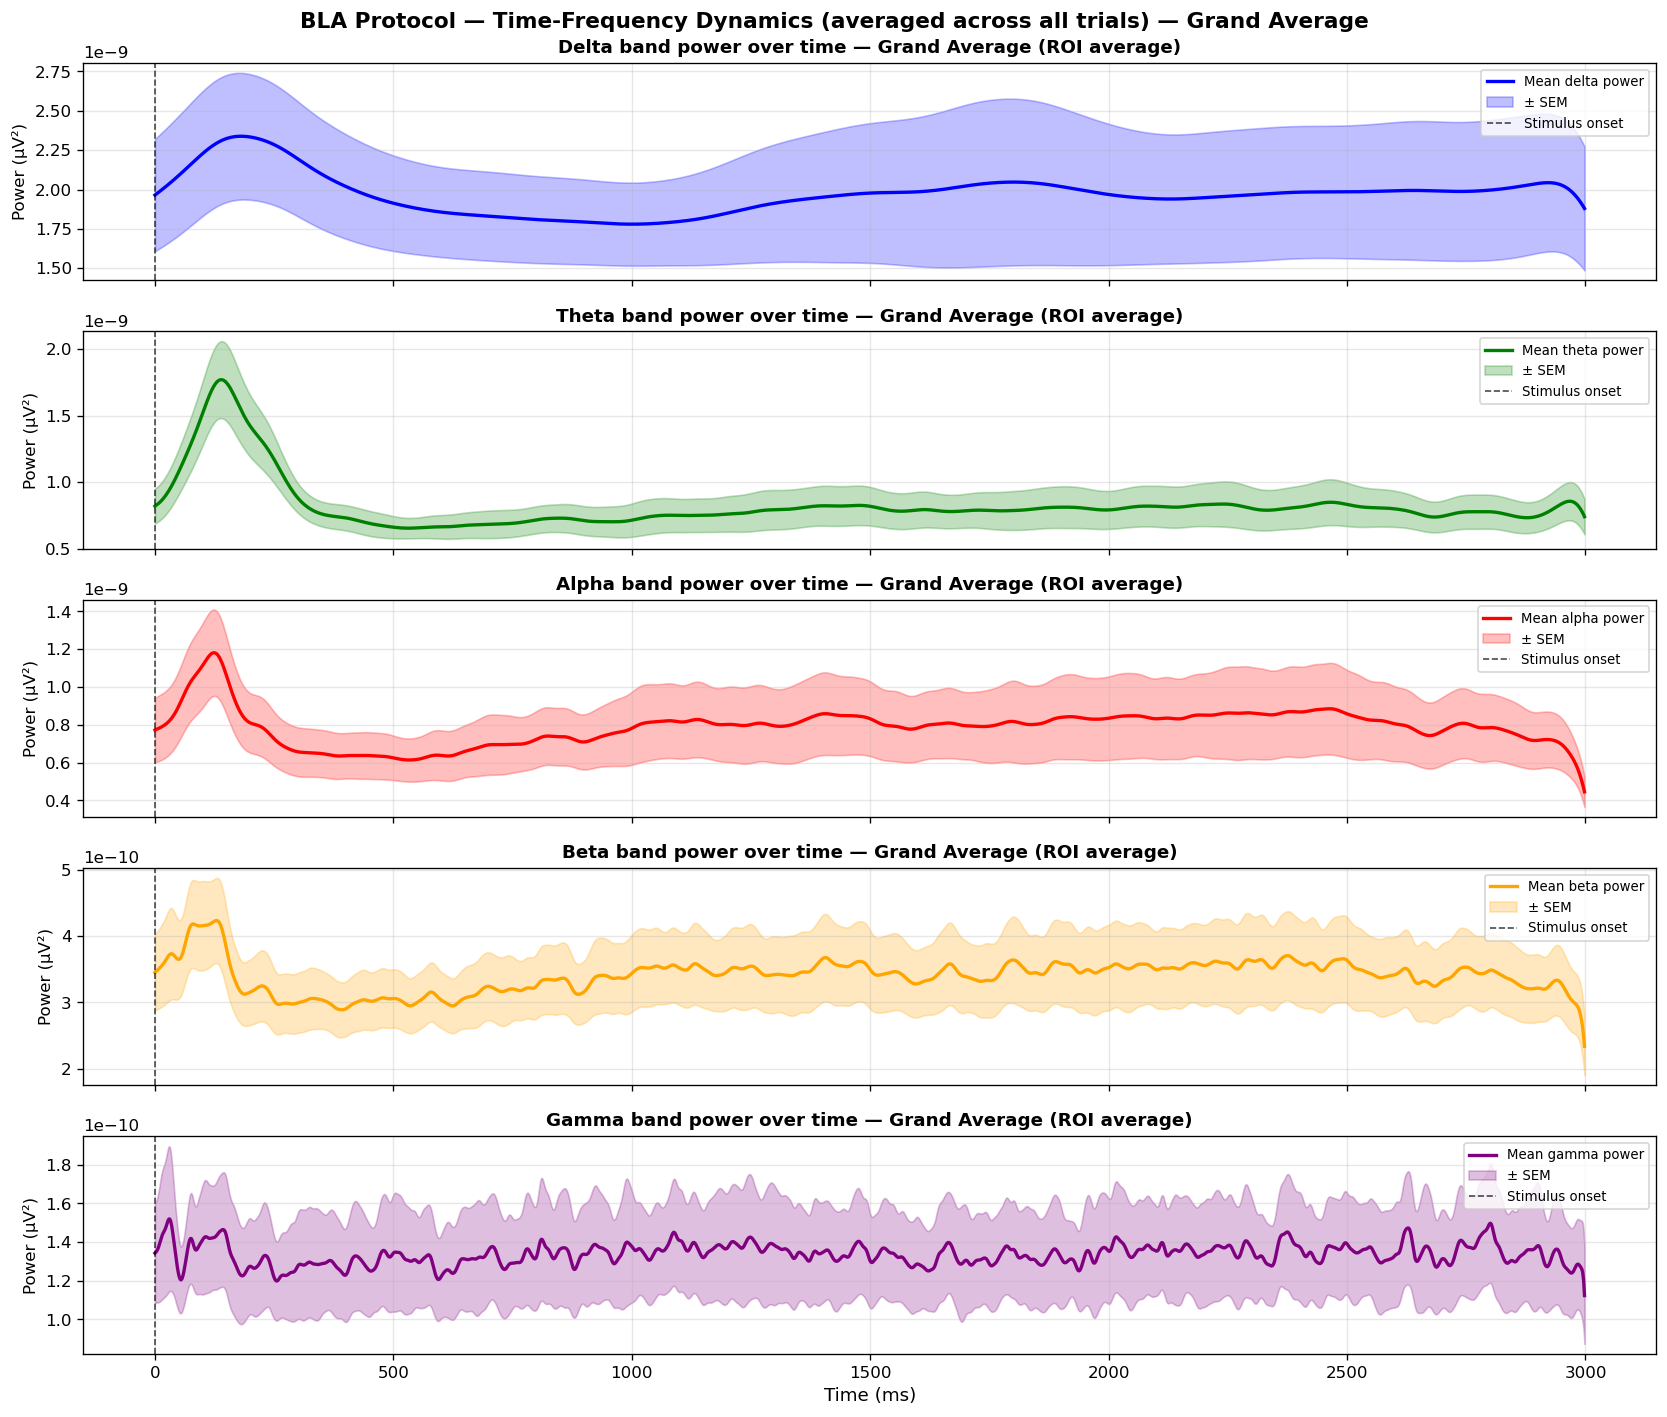

Figure saved: time_frequency_dynamics_BLA_grand_average.png


In [13]:
# Plot time-frequency power dynamics over time (grand average across subjects)
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

# ------------------------------------------------------------
# Each subject contributes one mean time course per band:
#   subject_mean(time) = average across that subject's trials
# Then the notebook averages those subject-level curves together.
# This avoids overweighting a subject just because they have
# more trials than someone else.
# ------------------------------------------------------------

grand_tf_power = {}
grand_tf_sem = {}

for band in bands:
    band_subject_means = []

    for subject_id in tf_processed_subjects:
        if subject_id in tf_power_pivots and band in tf_power_pivots[subject_id]:
            pivot_data = tf_power_pivots[subject_id][band]
            subject_mean = pivot_data.mean(axis=0)
            band_subject_means.append(subject_mean.reset_index(drop=True))

    if band_subject_means:
        band_df = pd.concat(band_subject_means, axis=1)
        grand_tf_power[band] = band_df.mean(axis=1)
        grand_tf_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

first_subject = tf_processed_subjects[0]
available_bands = [band for band in bands if band in tf_power_pivots[first_subject]]
time_points = tf_power_pivots[first_subject][available_bands[0]].columns.values

fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]

    if band in grand_tf_power:
        mean_power = grand_tf_power[band].values
        errors = grand_tf_sem[band].values

        ax.plot(time_points, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} power')
        ax.fill_between(
            time_points,
            mean_power - errors,
            mean_power + errors,
            color=colors[i],
            alpha=0.25,
            label='± SEM across subjects'
        )

        ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus onset')

    ax.set_ylabel('Baseline-centered power', fontsize=10)
    ax.set_title(
        f'{band.capitalize()} band power over time — Grand Average (ROI average)',
        fontsize=11,
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)
fig.suptitle(
    'BLA Protocol — Time-Frequency Dynamics (baseline-centered, averaged across all trials)',
    fontsize=13,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('time_frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: time_frequency_dynamics_BLA_grand_average.png")
print("Positive values = above each trial's pre-stimulus baseline; negative values = below baseline.")

# BLA Time_Frequency Domain Relative Power

In [12]:
# Compute baseline-centered relative power for time-frequency analysis
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# ------------------------------------------------------------
# FIXED LOGIC:
# Use RAW time-frequency band power to compute each band's % of
# total power at every trial x time point. Then baseline-center
# those percentages using the mean % in -500 to -50 ms.
#
# This produces "change in relative power from baseline", so the
# 5 bands should sum to ~0 at each time point after centering.
# ------------------------------------------------------------

tf_relative_power_dfs = {}
tf_relative_power_pivots = {}
tf_relative_processed_subjects = []
tf_relative_failed_subjects = []

for subject_id in tf_processed_subjects:
    try:
        tf_pivot_raw = tf_power_pivots_raw[subject_id]
        available_bands = [band for band in bands if band in tf_pivot_raw]

        if not available_bands:
            raise ValueError("No frequency bands found in tf_power_pivots_raw for this subject.")

        total_power_at_time = None
        for band in available_bands:
            band_pivot = tf_pivot_raw[band].copy()
            if total_power_at_time is None:
                total_power_at_time = band_pivot.copy()
            else:
                total_power_at_time = total_power_at_time + band_pivot

        relative_tf_pivot = {}
        time_points = total_power_at_time.columns.values
        baseline_mask = (time_points >= -500) & (time_points <= -50)

        for band in available_bands:
            band_pivot = tf_pivot_raw[band].copy()
            relative_power = band_pivot.div(total_power_at_time) * 100

            # For each trial, subtract that trial's average baseline %
            baseline_mean = relative_power.loc[:, baseline_mask].mean(axis=1)
            relative_power_centered = relative_power.subtract(baseline_mean, axis=0)

            relative_tf_pivot[band] = relative_power_centered

        tf_relative_features = []
        for trial in total_power_at_time.index:
            for time_point in time_points:
                row = {
                    'trial': trial,
                    'time_ms': time_point
                }
                for band in available_bands:
                    row[f'{band}_relative_power'] = relative_tf_pivot[band].loc[trial, time_point]
                tf_relative_features.append(row)

        tf_relative_df = pd.DataFrame(tf_relative_features)

        tf_relative_power_dfs[subject_id] = tf_relative_df
        tf_relative_power_pivots[subject_id] = relative_tf_pivot
        tf_relative_processed_subjects.append(subject_id)

    except Exception as e:
        tf_relative_failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", tf_relative_processed_subjects)

if tf_relative_failed_subjects:
    print("\nFailed:")
    for subject_id, err in tf_relative_failed_subjects:
        print(f"Subject {subject_id}: {err}")

Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


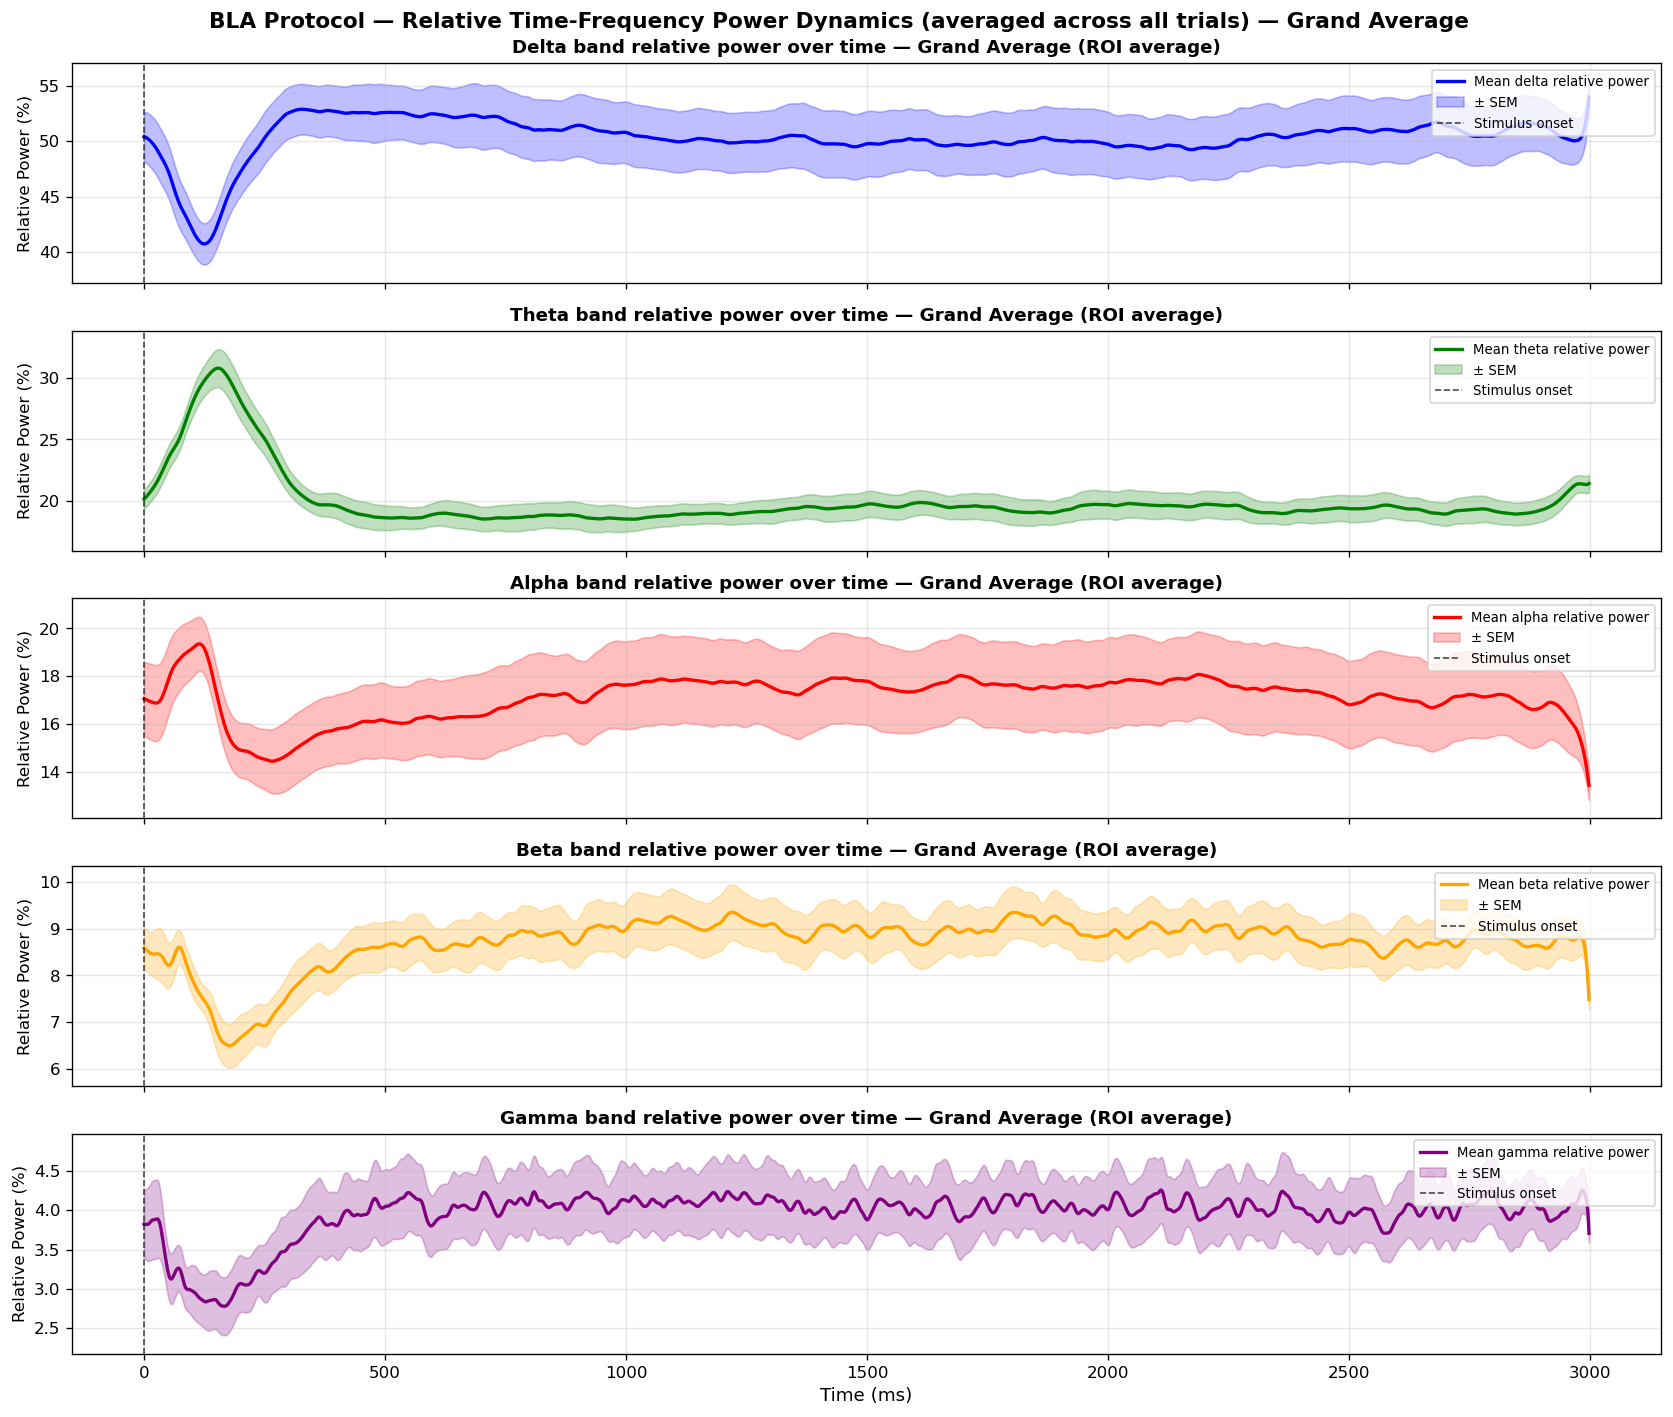

Figure saved: relative_time_frequency_dynamics_BLA_grand_average.png

Average relative power across time (Grand Average):
Delta: 50.3%
Theta: 19.9%
Alpha: 17.1%
Beta: 8.7%
Gamma: 3.9%

Grand-average summed relative power across bands:
Min: 100.000000
Max: 100.000000

First 10 time points:


0    100.0
1    100.0
2    100.0
3    100.0
4    100.0
5    100.0
6    100.0
7    100.0
8    100.0
9    100.0
dtype: float64

In [ ]:
# Plot relative time-frequency power dynamics over time (grand average across subjects)
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

grand_tf_relative_power = {}
grand_tf_relative_sem = {}

for band in bands:
    band_subject_means = []

    for subject_id in tf_relative_processed_subjects:
        if subject_id in tf_relative_power_pivots and band in tf_relative_power_pivots[subject_id]:
            pivot_data = tf_relative_power_pivots[subject_id][band]
            subject_mean = pivot_data.mean(axis=0)
            band_subject_means.append(subject_mean.reset_index(drop=True))

    if band_subject_means:
        band_df = pd.concat(band_subject_means, axis=1)
        grand_tf_relative_power[band] = band_df.mean(axis=1)
        grand_tf_relative_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

first_subject = tf_relative_processed_subjects[0]
available_bands = [band for band in bands if band in tf_relative_power_pivots[first_subject]]
time_points = tf_relative_power_pivots[first_subject][available_bands[0]].columns.values

fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]

    if band in grand_tf_relative_power:
        mean_power = grand_tf_relative_power[band].values
        errors = grand_tf_relative_sem[band].values

        ax.plot(time_points, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} relative power')
        ax.fill_between(
            time_points,
            mean_power - errors,
            mean_power + errors,
            color=colors[i],
            alpha=0.25,
            label='± SEM across subjects'
        )

        ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus onset')

        min_val = np.min(mean_power - errors)
        max_val = np.max(mean_power + errors)
        pad = 0.1 * (max_val - min_val) if max_val > min_val else 1
        ax.set_ylim(min_val - pad, max_val + pad)

    ax.set_ylabel('Baseline-centered relative power (%)', fontsize=10)
    ax.set_title(
        f'{band.capitalize()} band relative power over time — Grand Average (ROI average)',
        fontsize=11,
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)
fig.suptitle(
    'BLA Protocol — Relative Time-Frequency Power Dynamics (baseline-centered, averaged across all trials)',
    fontsize=13,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('relative_time_frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: relative_time_frequency_dynamics_BLA_grand_average.png")

print("\nAverage baseline-centered relative power across time (Grand Average):")
for band in bands:
    if band in grand_tf_relative_power:
        avg_relative_power = grand_tf_relative_power[band].mean()
        print(f"{band.capitalize()}: {avg_relative_power:.3f}%")

grand_sum = None
for band in bands:
    if band in grand_tf_relative_power:
        if grand_sum is None:
            grand_sum = grand_tf_relative_power[band].copy()
        else:
            grand_sum = grand_sum + grand_tf_relative_power[band]

print("\nGrand-average summed baseline-centered relative power across bands:")
print("These should be close to 0% because baseline-centering removes the baseline composition.")
print(f"Min: {grand_sum.min():.6f}")
print(f"Max: {grand_sum.max():.6f}")
print("\nFirst 10 time points:")
display(grand_sum.head(10))

# Filter vs No Filter Comparison

/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/Users/zach/opt/anaconda3/envs/eeg-env/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 231, using nperseg = 231
  freqs, _, Pxy = _spectral_helper(x, y,

Processed successfully in both: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


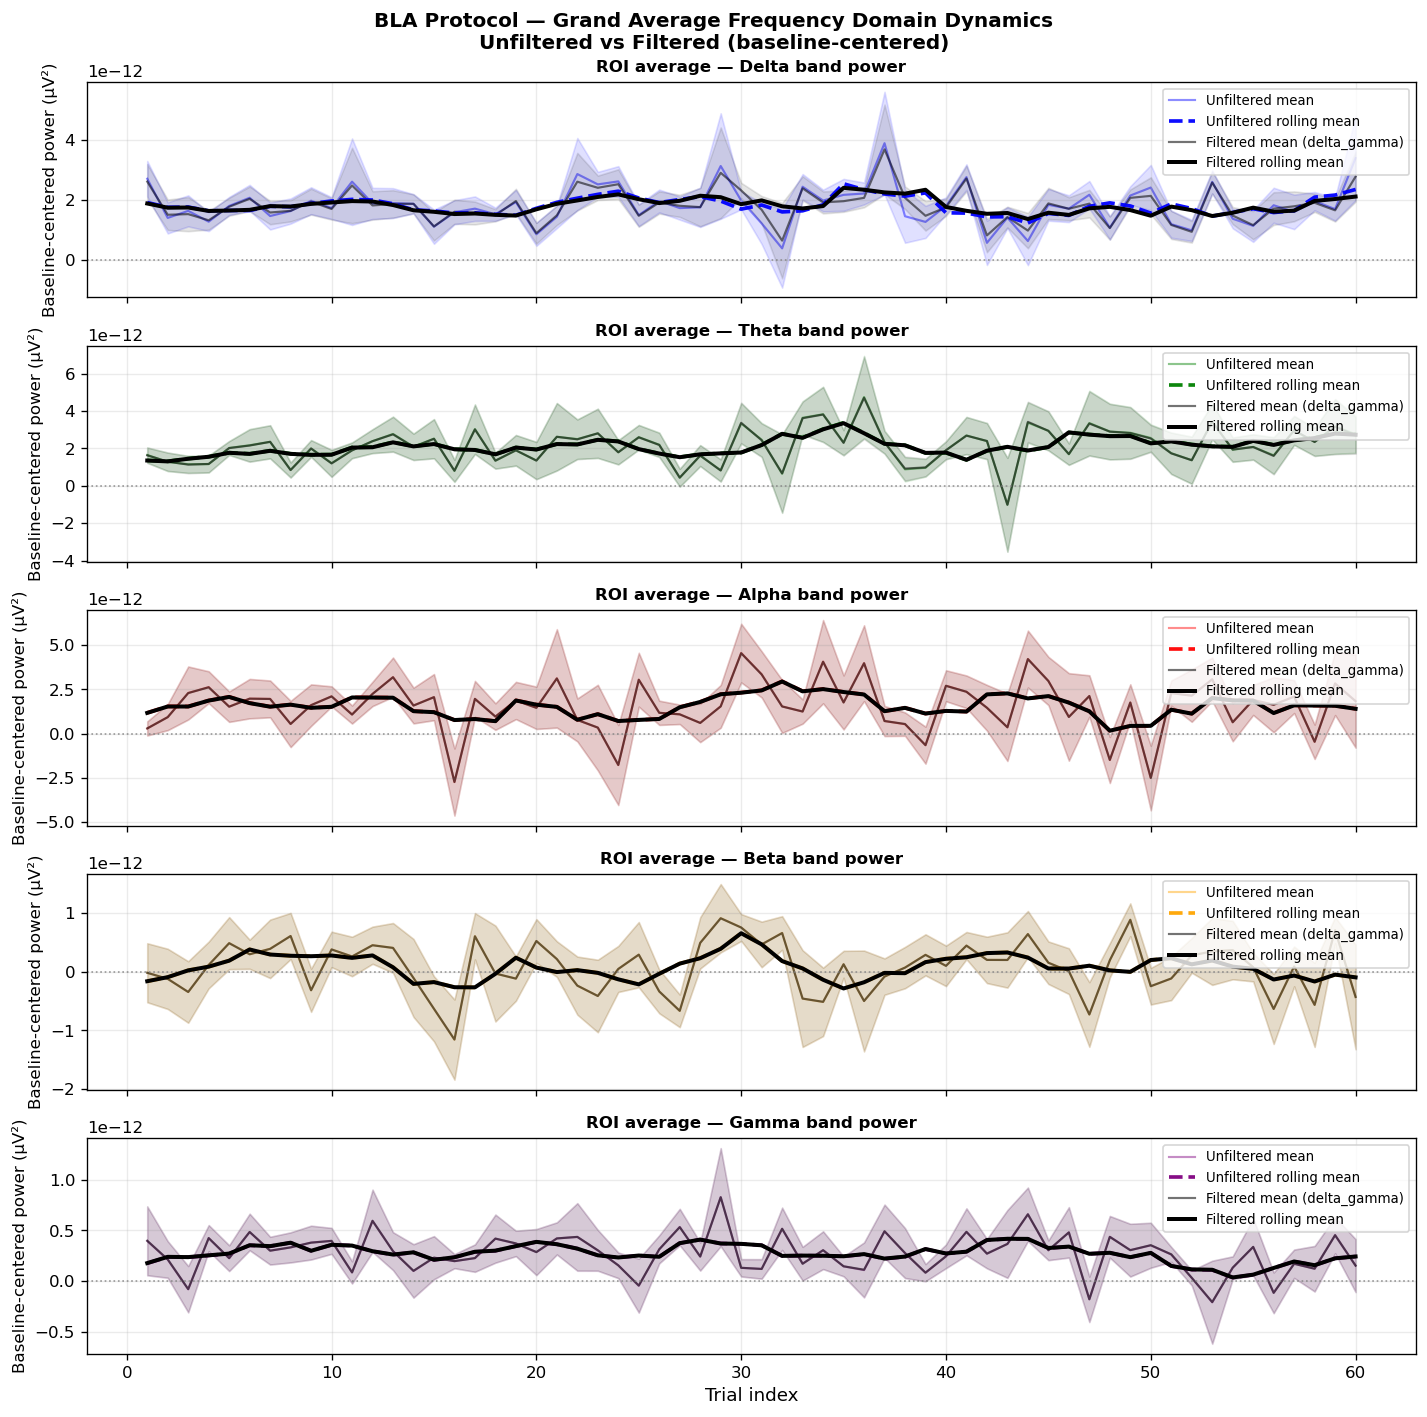


Figure saved: frequency_dynamics_BLA_filtered_vs_unfiltered.png
Dashed colored/black lines are rolling means; lighter bands show SEM across subjects.


In [13]:
import warnings
import contextlib
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# GOAL:
# Compare grand-average BASELINE-CENTERED absolute band power
# across trials for:
#   1) unfiltered EEG data
#   2) filtered EEG data
#
# Both conditions are processed in the same way:
#   raw band power -> baseline band power -> subtract baseline
#
# This makes the comparison fairer because both curves are shown
# relative to the subject's own pre-stimulus activity.
# ------------------------------------------------------------

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = {
    'delta': 'blue',
    'theta': 'green',
    'alpha': 'red',
    'beta': 'orange',
    'gamma': 'purple'
}
FILTER_BAND = "delta_gamma"

all_power_pivots_unfiltered = {}
baseline_power_pivots_unfiltered = {}
all_power_pivots_filtered = {}
baseline_power_pivots_filtered = {}

processed_unfiltered = []
processed_filtered = []
failed_unfiltered = []
failed_filtered = []

for subject_id in SUBJECTS:

    # ---------------------------
    # A) UNFILTERED DATA
    # ---------------------------
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs_unf = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS
                )

        baseline_epochs_unf = epochs_unf.copy().crop(tmin=-0.5, tmax=-0.05)
        baseline_power_df_unf, _ = compute_frequency_power(baseline_epochs_unf, fmin=0.5, fmax=45)
        baseline_power_pivot_unf = baseline_power_df_unf.groupby(['trial', 'band'])['power'].mean().unstack().reindex(columns=bands)

        power_df_unf, _ = compute_frequency_power(epochs_unf, fmin=0.5, fmax=45)
        power_pivot_unf = power_df_unf.groupby(['trial', 'band'])['power'].mean().unstack().reindex(columns=bands)

        power_pivot_unf = power_pivot_unf.subtract(baseline_power_pivot_unf, fill_value=0)

        all_power_pivots_unfiltered[subject_id] = power_pivot_unf
        baseline_power_pivots_unfiltered[subject_id] = baseline_power_pivot_unf
        processed_unfiltered.append(subject_id)

    except Exception as e:
        failed_unfiltered.append((subject_id, str(e)))

    # ---------------------------
    # B) FILTERED DATA
    # ---------------------------
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs_filt = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band=FILTER_BAND
                )

        baseline_epochs_filt = epochs_filt.copy().crop(tmin=-0.5, tmax=-0.05)
        baseline_power_df_filt, _ = compute_frequency_power(baseline_epochs_filt, fmin=0.5, fmax=45)
        baseline_power_pivot_filt = baseline_power_df_filt.groupby(['trial', 'band'])['power'].mean().unstack().reindex(columns=bands)

        power_df_filt, _ = compute_frequency_power(epochs_filt, fmin=0.5, fmax=45)
        power_pivot_filt = power_df_filt.groupby(['trial', 'band'])['power'].mean().unstack().reindex(columns=bands)

        power_pivot_filt = power_pivot_filt.subtract(baseline_power_pivot_filt, fill_value=0)

        all_power_pivots_filtered[subject_id] = power_pivot_filt
        baseline_power_pivots_filtered[subject_id] = baseline_power_pivot_filt
        processed_filtered.append(subject_id)

    except Exception as e:
        failed_filtered.append((subject_id, str(e)))

common_subjects = sorted(set(processed_unfiltered) & set(processed_filtered))
print("Processed successfully in both:", common_subjects)

if failed_unfiltered:
    print("\nUnfiltered failed:")
    for subject_id, err in failed_unfiltered:
        print(f"Subject {subject_id}: {err}")

if failed_filtered:
    print("\nFiltered failed:")
    for subject_id, err in failed_filtered:
        print(f"Subject {subject_id}: {err}")

# ------------------------------------------------------------
# Build subject-by-trial matrices for each band. We also compute
# SEM so the comparison plot is easier to interpret.
# ------------------------------------------------------------

grand_power_unfiltered = {}
grand_sem_unfiltered = {}
grand_power_filtered = {}
grand_sem_filtered = {}

for band in bands:
    band_trials_unf = []
    band_trials_filt = []

    for subject_id in common_subjects:
        pivot_unf = all_power_pivots_unfiltered[subject_id]
        pivot_filt = all_power_pivots_filtered[subject_id]

        if band in pivot_unf.columns:
            band_trials_unf.append(pivot_unf[band].reset_index(drop=True))

        if band in pivot_filt.columns:
            band_trials_filt.append(pivot_filt[band].reset_index(drop=True))

    if band_trials_unf:
        df_unf = pd.concat(band_trials_unf, axis=1)
        grand_power_unfiltered[band] = df_unf.mean(axis=1)
        grand_sem_unfiltered[band] = df_unf.std(axis=1) / np.sqrt(df_unf.shape[1])

    if band_trials_filt:
        df_filt = pd.concat(band_trials_filt, axis=1)
        grand_power_filtered[band] = df_filt.mean(axis=1)
        grand_sem_filtered[band] = df_filt.std(axis=1) / np.sqrt(df_filt.shape[1])

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]
    color = colors[band]

    if band in grand_power_unfiltered:
        values_unf = grand_power_unfiltered[band].values
        errors_unf = grand_sem_unfiltered[band].values
        trial_idx_unf = np.arange(1, len(values_unf) + 1)

        ax.plot(
            trial_idx_unf, values_unf,
            color=color, linewidth=1.3, alpha=0.45, zorder=1, label='Unfiltered mean'
        )
        ax.fill_between(
            trial_idx_unf,
            values_unf - errors_unf,
            values_unf + errors_unf,
            color=color,
            alpha=0.12,
            zorder=1
        )

        rolling_unf = pd.Series(values_unf).rolling(
            window=ROLLING_WINDOW, center=True, min_periods=1
        ).mean()

        ax.plot(
            trial_idx_unf, rolling_unf,
            color=color, linewidth=2.2, alpha=0.95, linestyle='--',
            zorder=3, label='Unfiltered rolling mean'
        )

    if band in grand_power_filtered:
        values_filt = grand_power_filtered[band].values
        errors_filt = grand_sem_filtered[band].values
        trial_idx_filt = np.arange(1, len(values_filt) + 1)

        ax.plot(
            trial_idx_filt, values_filt,
            color='black', linewidth=1.3, alpha=0.55, zorder=2, label=f'Filtered mean ({FILTER_BAND})'
        )
        ax.fill_between(
            trial_idx_filt,
            values_filt - errors_filt,
            values_filt + errors_filt,
            color='black',
            alpha=0.10,
            zorder=2
        )

        rolling_filt = pd.Series(values_filt).rolling(
            window=ROLLING_WINDOW, center=True, min_periods=1
        ).mean()

        ax.plot(
            trial_idx_filt, rolling_filt,
            color='black', linewidth=2.4, zorder=4, label='Filtered rolling mean'
        )

    ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.8)
    ax.set_ylabel('Baseline-centered power (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    'BLA Protocol — Grand Average Frequency Domain Dynamics\nUnfiltered vs Filtered (baseline-centered)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_filtered_vs_unfiltered.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nFigure saved: frequency_dynamics_BLA_filtered_vs_unfiltered.png")
print("Dashed colored/black lines are rolling means; lighter bands show SEM across subjects.")